In [1]:
from google.colab import files
uploaded = files.upload()   # Upload kaggle.json here

!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API configured")

# Download dataset
!rm -f /content/*.zip
!kaggle datasets download -d shoybhasan/camus-human-heart-data -p /content --force

# Unzip first layer
!rm -rf /content/camus_data
!mkdir -p /content/camus_data
!unzip -q /content/camus-human-heart-data.zip -d /content/camus_data

# Unzip nested archive
!rm -rf /content/camus_full
!mkdir -p /content/camus_full
!unzip -q /content/camus_data/download -d /content/camus_full

import os

root_dir = "/content/camus_full/database_nifti"

print("Using dataset root:", root_dir)
print("Number of patient folders:", len(os.listdir(root_dir)))
print("Example folders:", os.listdir(root_dir)[:5])

Saving kaggle.json to kaggle.json
Kaggle API configured
Dataset URL: https://www.kaggle.com/datasets/shoybhasan/camus-human-heart-data
License(s): other
100% 3.50G/3.50G [01:47<00:00, 35.0MB/s]

Using dataset root: /content/camus_full/database_nifti
Number of patient folders: 500
Example folders: ['patient0155', 'patient0142', 'patient0116', 'patient0084', 'patient0150']


In [2]:
import os
import cv2
import random
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

IMAGE_SIZE = 512

In [3]:
def collect_pairs(patient_list, root_dir):
    pairs = []

    for patient in patient_list:
        p_dir = os.path.join(root_dir, patient)
        files = os.listdir(p_dir)

        image_files = [
            f for f in files
            if f.endswith(".nii.gz") and not f.endswith("_gt.nii.gz")
        ]

        for img_file in image_files:
            mask_file = img_file.replace(".nii.gz", "_gt.nii.gz")
            img_path = os.path.join(p_dir, img_file)
            mask_path = os.path.join(p_dir, mask_file)

            if os.path.exists(mask_path):
                pairs.append((img_path, mask_path))

    return sorted(pairs)

patients = sorted([
    p for p in os.listdir(root_dir)
    if os.path.isdir(os.path.join(root_dir, p))
])

all_pairs = collect_pairs(patients, root_dir)

print("Total patients:", len(patients))
print("Total image-mask pairs:", len(all_pairs))
print("Example pair:")
print(all_pairs[0])

Total patients: 500
Total image-mask pairs: 3000
Example pair:
('/content/camus_full/database_nifti/patient0001/patient0001_2CH_ED.nii.gz', '/content/camus_full/database_nifti/patient0001/patient0001_2CH_ED_gt.nii.gz')


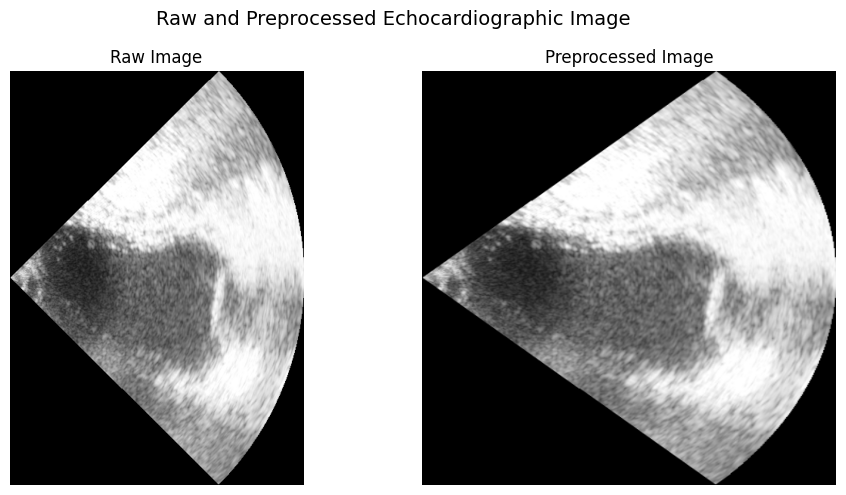

Saved figure to: /content/raw_vs_preprocessed.png
Image used: patient0001_2CH_ED.nii.gz


In [4]:
# Select one sample from the full dataset
sample_idx = 0   # you can change this to try another image
sample_img_path, sample_mask_path = all_pairs[sample_idx]

# -----------------------------
# Load raw image
# -----------------------------
raw_img = np.asanyarray(nib.load(sample_img_path).dataobj).astype(np.float32)

# If image is 3D, take the first slice/frame (same logic as Week 7 dataset class)
if raw_img.ndim == 3:
    raw_img = raw_img[:, :, 0]

# -----------------------------
# Resize to 512 × 512
# -----------------------------
resized_img = cv2.resize(
    raw_img,
    (IMAGE_SIZE, IMAGE_SIZE),
    interpolation=cv2.INTER_LINEAR
)

# -----------------------------
# Min-max normalisation
# -----------------------------
norm_img = (resized_img - resized_img.min()) / (resized_img.max() - resized_img.min() + 1e-8)

# -----------------------------
# Same final normalisation used in Week 7 val_transform:
# A.Normalize(mean=(0.5,), std=(0.5,))
# For display, convert back to [0,1]
# -----------------------------
preprocessed_img = (norm_img - 0.5) / 0.5
preprocessed_display = (preprocessed_img + 1) / 2
preprocessed_display = np.clip(preprocessed_display, 0, 1)

# -----------------------------
# Plot raw vs preprocessed
# -----------------------------
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(raw_img, cmap="gray")
plt.title("Raw Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(preprocessed_display, cmap="gray")
plt.title("Preprocessed Image")
plt.axis("off")

plt.suptitle("Raw and Preprocessed Echocardiographic Image", fontsize=14)
plt.tight_layout()

# Save figure
output_path = "/content/raw_vs_preprocessed.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:", output_path)
print("Image used:", os.path.basename(sample_img_path))

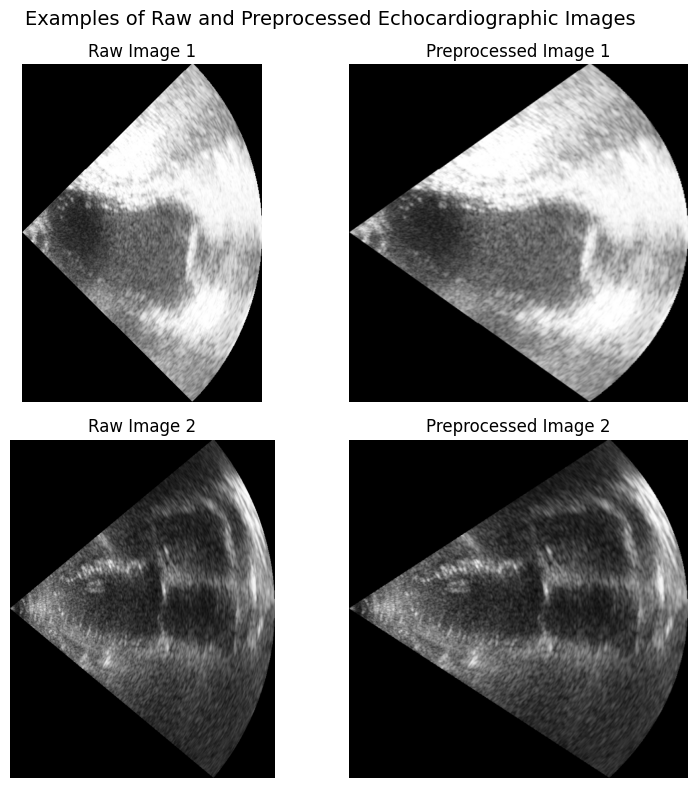

Saved figure to: /content/raw_vs_preprocessed_examples.png


In [5]:
sample_indices = [0, 10]   # change if you want

fig, axes = plt.subplots(len(sample_indices), 2, figsize=(8, 4 * len(sample_indices)))

if len(sample_indices) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, idx in enumerate(sample_indices):
    sample_img_path, _ = all_pairs[idx]

    raw_img = np.asanyarray(nib.load(sample_img_path).dataobj).astype(np.float32)
    if raw_img.ndim == 3:
        raw_img = raw_img[:, :, 0]

    resized_img = cv2.resize(raw_img, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_LINEAR)
    norm_img = (resized_img - resized_img.min()) / (resized_img.max() - resized_img.min() + 1e-8)

    preprocessed_img = (norm_img - 0.5) / 0.5
    preprocessed_display = (preprocessed_img + 1) / 2
    preprocessed_display = np.clip(preprocessed_display, 0, 1)

    axes[row, 0].imshow(raw_img, cmap="gray")
    axes[row, 0].set_title(f"Raw Image {row+1}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(preprocessed_display, cmap="gray")
    axes[row, 1].set_title(f"Preprocessed Image {row+1}")
    axes[row, 1].axis("off")

plt.suptitle("Examples of Raw and Preprocessed Echocardiographic Images", fontsize=14)
plt.tight_layout()

output_path_multi = "/content/raw_vs_preprocessed_examples.png"
plt.savefig(output_path_multi, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:", output_path_multi)